In [20]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl

# Project 1: quantifying cell movement from microscopy data 

### dataset 1.1: cells moving with no drug added 
migration_no_drug_low_density.pkl, 
migration_no_drug_med_density.pkl, 
migration_no_drug_high_density.pkl

Cell centroids are saved in A_list, which has shape (t, x, y). For each time point t, there is a spatial field of cells in the xy-plane, where 1's denote location of cells. See metadata for spatial length scale and interval between time points.

Size of data (t, 2D position):  (41, 40, 40)

Data Details: 
experiment - no drug
cell density - med
movie frames - 41
xy dimensions - 40
microns per lattice space - 1
time interval (mins) - 5


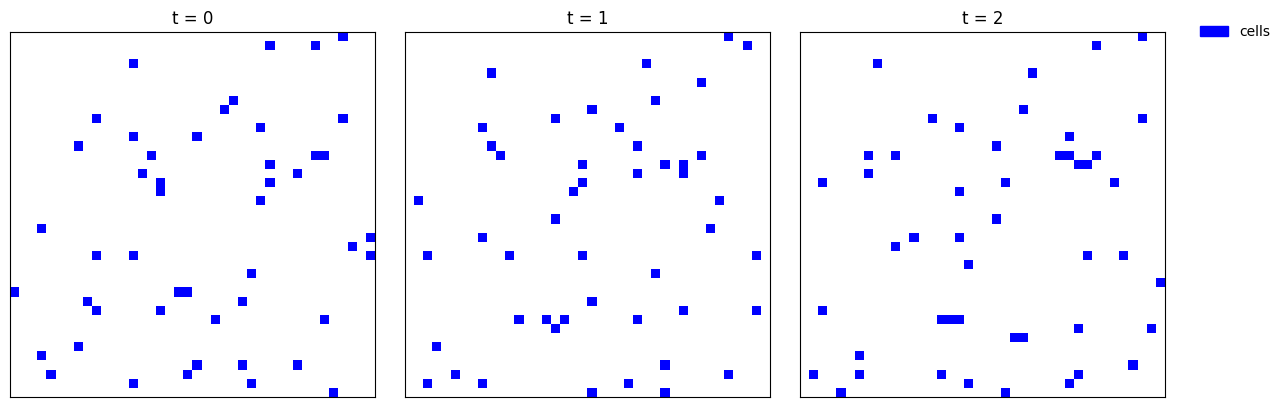

In [28]:
# example of loading and plotting data:

with open("migration_no_drug_med_density.pkl", "rb") as f:
    output = pickle.load(f)

A_list = output["A_list"] 
metadata = output["metadata"]

print("Size of data (t, 2D position): ", np.shape(A_list)) 
print("\nData Details: ")
for key,value in metadata.items():
    print(key, "-",  value)

# discrete colormap:
cmaplist = [
    (1.0, 1.0, 1.0, 1.0),          # 0 empty
    (0.0, 0.0, 1.0, 1.0),          # 1 cell
]
cmap = mpl.colors.ListedColormap(cmaplist)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axes):
    ax.imshow(A_list[i], cmap=cmap) 
    ax.set_title(f"t = {i}")
    ax.set_xticks([]); ax.set_yticks([])

legend_patches = [
    mpl.patches.Patch(color=cmaplist[1], label='cells'),
]
fig.legend(handles=legend_patches, bbox_to_anchor=(1.0, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


#### dataset 1.2: cells moving with drug added

migration_with_drug_low_density.pkl, 
migration_with_drug_med_density.pkl, 
migration_with_drug_high_density.pkl

Cell centroids are saved saved in A_list, which has shape (t, x, y). For each time point t, there is a spatial field of cells in the xy-plane, where 1's denote location of cells. See metadata for spatial length scale and interval between time points.

In [3]:
# load and plot like above

# Project 2: determining effect of drug on cell-to-cell virus transmission

#### dataset 2.1: virus spreading with no drug added

infection_no_drug_experiment_0.pkl, 
infection_no_drug_experiment_1.pkl, 
infection_no_drug_experiment_2.pkl

Cell centroids are again saved in A_list, which has shape (t, x, y). For each time point t, there is a spatial field of cells in the xy-plane, where each value encodes the cell's state: 0 = no cell, 1 = susceptible cell, 2 = infected cell, 3 = recovered cell. For example, A_list[t][x, y] == 2 means the cell at position (x, y) is infected at frame t.

See metadata for spatial length scale and interval between time points.

The biologists collected 3 movies (experiments 0, 1, and 2)


Size of data (t, 2D position):  (401, 40, 40)

Data Details: 
experiment - infection without drug
movie frames - 401
xy dimensions - 40
microns per lattice space - 1
time interval (mins) - 0.5


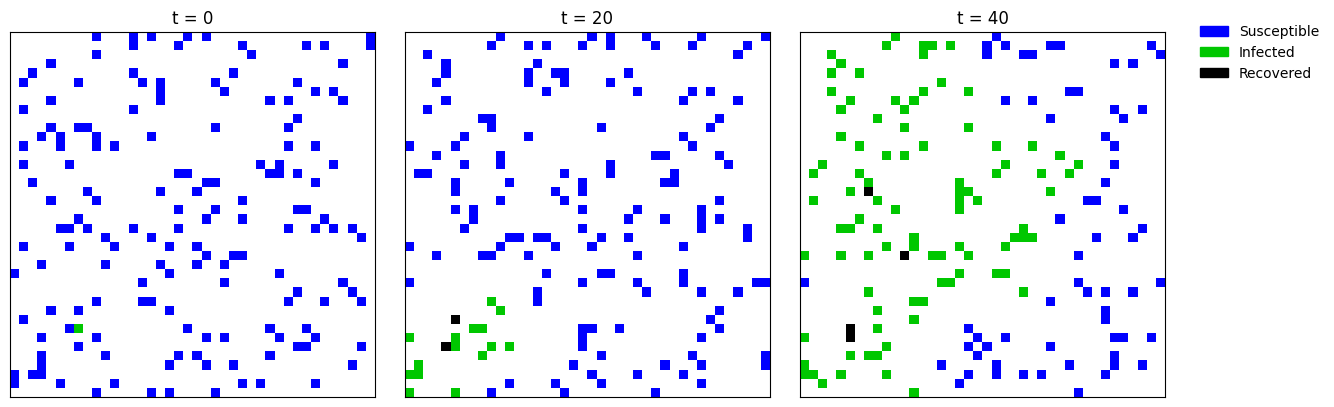

In [30]:
# example of loading and plotting data:

with open("infection_no_drug_experiment_0.pkl", "rb") as f:
    output = pickle.load(f)

A_list = output["A_list"]
metadata = output["metadata"]

print("Size of data (t, 2D position): ", np.shape(A_list)) 
print("\nData Details: ")
for key,value in metadata.items():
    print(key, "-",  value)

# discrete colormap: one color per state (0=empty, 1=S, 2=I, 3=R)
cmaplist = [
    (1.0, 1.0, 1.0, 1.0),          # 0 empty
    (0.0, 0.0, 1.0, 1.0),          # 1 susceptible
    (0.0, 200/256, 0.0, 1.0),      # 2 infected
    (0.0, 0.0, 0.0, 1.0),          # 3 recovered
]
cmap = mpl.colors.ListedColormap(cmaplist)

times_to_plot = [0, 20, 40]   

fig, axes = plt.subplots(1, len(times_to_plot), figsize=(4*len(times_to_plot), 4))
axes = np.atleast_1d(axes)   

for ax, t in zip(axes, times_to_plot):
    ax.imshow(A_list[t], cmap=cmap, vmin=-0.5, vmax=3.5)  #need vmin and vmax to keep from rescaling
    ax.set_title(f"t = {t}")
    ax.set_xticks([]); ax.set_yticks([])

legend_patches = [
    mpl.patches.Patch(color=cmaplist[1], label='Susceptible'),
    mpl.patches.Patch(color=cmaplist[2], label='Infected'),
    mpl.patches.Patch(color=cmaplist[3], label='Recovered'),
]
fig.legend(handles=legend_patches, bbox_to_anchor=(1.0, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()



#### dataset 2.2: virus spreading with drug added

infection_with_drug_experiment_0.pkl
infection_with_drug_experiment_1.pkl
infection_with_drug_experiment_2.pkl

Cell centroids are again saved in A_list, which has shape (t, x, y). For each time point t, there is a spatial field of cells in the xy-plane, where each value encodes the cell's state: 0 = no cell, 1 = susceptible cell, 2 = infected cell, 3 = recovered cell. For example, A_list[t][x, y] == 2 means the cell at position (x, y) is infected at frame t.

See metadata for spatial length scale and interval between time points.

The biologists collected 3 movies (experiments 0, 1, and 2)

In [5]:
# load and plot like above